In [1]:
import scanpy as sc
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

In [2]:
gf_dir = large_data_dir + 'gf_CL3_HB_Betaine/BC1_giftwrap/'
adata_path = large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad'


9362534 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 9342599 UMIs remaining (99.79%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 7969820 UMIs remaining (85.12%)


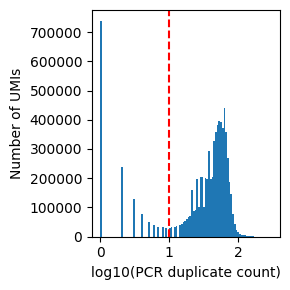

In [3]:
manifest = pd.read_csv('../data/manifest_gapfill_1plex.tsv', sep='\t')

manifest.loc[manifest['gap_probe_sequence'].isna(), 'name'] = manifest.loc[manifest['gap_probe_sequence'].isna(),'name'] + ' 0bp' ## annotate non-variant probes as 0bp
manifest['type'] = 'gapfill'
manifest.loc[manifest['name'].str.contains('0bp'),'type'] = '0bp_control'
manifest['variant'] = None ### not relevant for gapfill but maintained for consistency

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path)
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start','variant']], left_on='probe_idx',right_index=True, how='left')

read_threshold = 10
gf_utils.plot_reads_per_umi(probe_reads=probe_reads, read_threshold=read_threshold)

probe_reads = probe_reads.loc[probe_reads['pcr_duplicate_count'] > read_threshold].copy()


In [4]:
mutations = pd.read_csv('../data/3cl_predicted_genotypes.csv',index_col=0)
mutations['genotype_from_bulk'] = mutations['genotype_from_bulk'].map({'homozygous_ref': 0, 'heterozygous': 1, 'homozygous_alt': 2})
mutations_pivot = mutations.pivot(index='name', columns='cell_type', values='genotype_from_bulk').dropna()
K562_mutations = mutations_pivot.loc[((mutations_pivot['K562'] == 2) | (mutations_pivot['K562'] == 1)) & (mutations_pivot['SET2'] == 0)]
SET2_mutations = mutations_pivot.loc[(mutations_pivot['K562'] == 0) & ((mutations_pivot['SET2'] == 2) | (mutations_pivot['SET2'] == 1))]


In [5]:
K562_counts = probe_reads.loc[(probe_reads['name'].isin(K562_mutations.index)) & (probe_reads['gapfill'] == probe_reads['gap_probe_sequence'])].groupby(['barcode','cell_type']).size().reset_index()
SET2_counts = probe_reads.loc[(probe_reads['name'].isin(SET2_mutations.index)) & (probe_reads['gapfill'] == probe_reads['gap_probe_sequence'])].groupby(['barcode','cell_type']).size().reset_index()

K562_counts = K562_counts.loc[K562_counts['cell_type'].isin(['K562','SET2'])]
SET2_counts = SET2_counts.loc[SET2_counts['cell_type'].isin(['K562','SET2'])]

/tmp/ipykernel_62158/1519559065.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  K562_counts = probe_reads.loc[(probe_reads['name'].isin(K562_mutations.index)) & (probe_reads['gapfill'] == probe_reads['gap_probe_sequence'])].groupby(['barcode','cell_type']).size().reset_index()
/tmp/ipykernel_62158/1519559065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SET2_counts = probe_reads.loc[(probe_reads['name'].isin(SET2_mutations.index)) & (probe_reads['gapfill'] == probe_reads['gap_probe_sequence'])].groupby(['barcode','cell_type']).size().reset_index()


In [6]:
merged = K562_counts.merge(SET2_counts, on=['barcode','cell_type'], how='outer', suffixes=('_K562', '_SET2'))
merged.columns = ['barcode', 'cell_type','K562_mutation_count', 'SET2_mutation_count']

merged[['K562_mutation_count','SET2_mutation_count']] = merged[['K562_mutation_count','SET2_mutation_count']].fillna(0)
merged = merged.loc[merged[['K562_mutation_count','SET2_mutation_count']].sum(axis=1) > 0]


/tmp/ipykernel_62158/1909061280.py:8: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(['K562', 'SET2'], labels=['K-562', 'SET-2'],


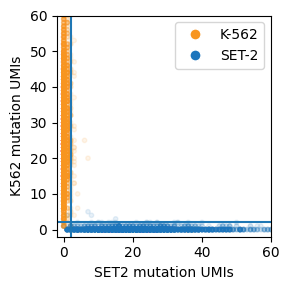

In [7]:
to_plot = merged[['K562_mutation_count','SET2_mutation_count','cell_type']]

fig,ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(to_plot['SET2_mutation_count'],to_plot['K562_mutation_count'],c = to_plot['cell_type'].map({'K562':'#F79520', 'SET2':'#1c75bc'}),alpha=0.1,s=10)
ax.set_ylabel('K562 mutation UMIs')
ax.set_xlabel('SET2 mutation UMIs')

ax.legend(['K562', 'SET2'], labels=['K-562', 'SET-2'], 
          handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F79520', markersize=8),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1c75bc', markersize=8)])

ax.set_xlim(-2,60)
ax.set_ylim(-2,60)

ax.axhline(2)
ax.axvline(2)
plt.tight_layout()
plt.savefig('../plots/gapfill_barnyard_plot.pdf')

In [8]:
## get cell counts
to_plot['cell_type'].value_counts()

cell_type
K562    3134
SET2    2823
HEL        0
Name: count, dtype: int64

In [9]:
## get accuracy

merged.loc[merged['cell_type'] == 'K562','correct_counts'] = merged.loc[merged['cell_type'] == 'K562']['K562_mutation_count']
merged.loc[merged['cell_type'] == 'K562','incorrect_counts'] = merged.loc[merged['cell_type'] == 'K562']['SET2_mutation_count']
merged.loc[merged['cell_type'] == 'SET2','correct_counts'] = merged.loc[merged['cell_type'] == 'SET2']['SET2_mutation_count']
merged.loc[merged['cell_type'] == 'SET2','incorrect_counts'] = merged.loc[merged['cell_type'] == 'SET2']['K562_mutation_count']
merged['correct_counts'].sum() / (merged['correct_counts'].sum() + merged['incorrect_counts'].sum())

0.9929539974321235